# Advanced Exploratory Data Analysis

This notebook focuses on advanced climate analysis, geographical patterns, environmental relationships, and feature exploration within the global weather dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/GlobalWeatherRepository.csv")

df['last_updated'] = pd.to_datetime(df['last_updated'])

## Average Temperature by Country

This section explores how average temperatures vary across different countries and regions.

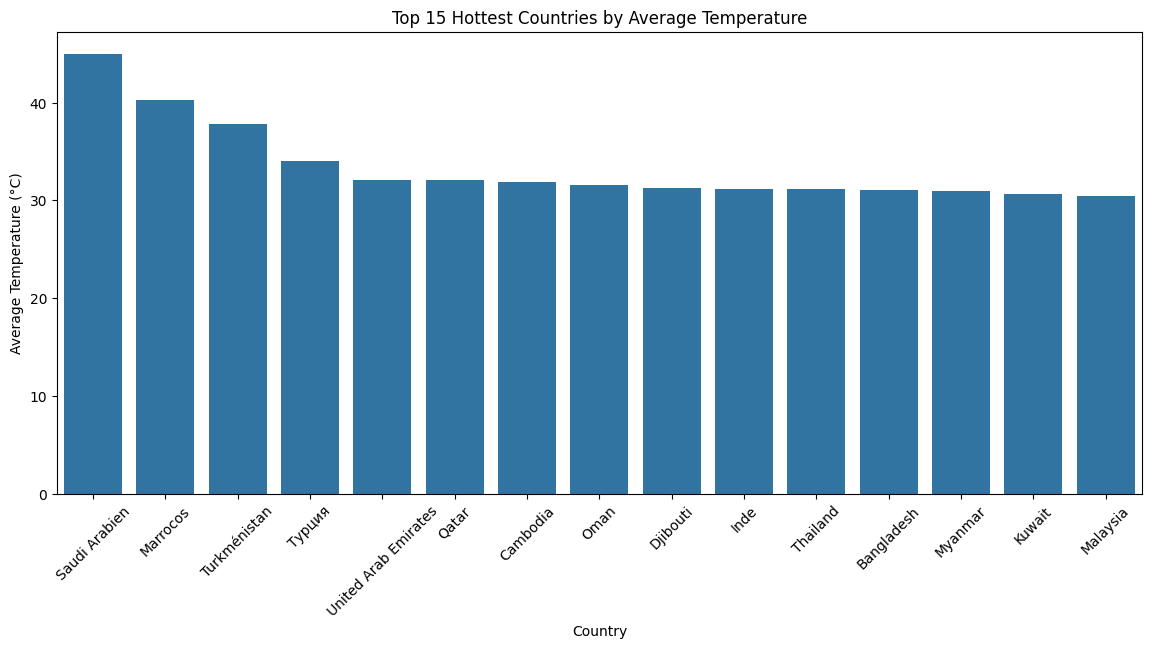

In [2]:
country_temp = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=country_temp.index,
    y=country_temp.values
)

plt.xticks(rotation=45)

plt.title('Top 15 Hottest Countries by Average Temperature')
plt.xlabel('Country')
plt.ylabel('Average Temperature (°C)')

plt.show()

## Country Temperature Insights

- Countries in warmer geographic regions dominate the highest average temperature rankings.
- Middle Eastern and tropical countries exhibit consistently high temperatures.
- The analysis highlights strong geographical influences on climate patterns.

## Coldest Countries by Average Temperature

This section explores countries with the lowest average recorded temperatures in the dataset.

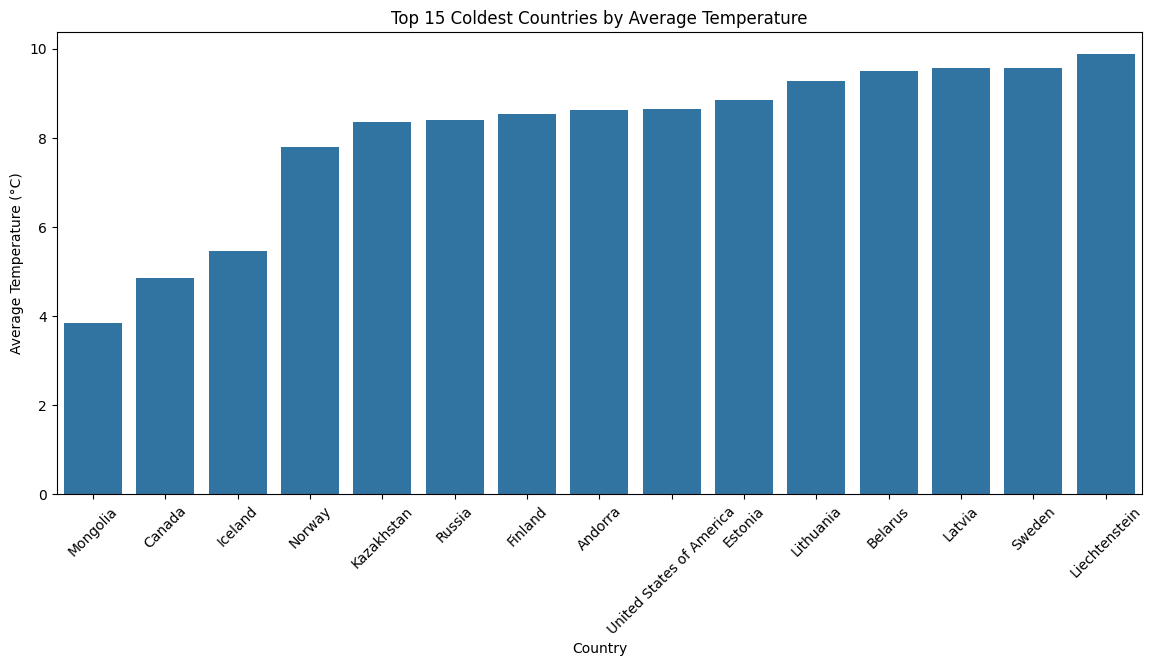

In [3]:
coldest_countries = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=True)
    .head(15)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=coldest_countries.index,
    y=coldest_countries.values
)

plt.xticks(rotation=45)

plt.title('Top 15 Coldest Countries by Average Temperature')
plt.xlabel('Country')
plt.ylabel('Average Temperature (°C)')

plt.show()

## Cold Climate Insights

- Northern and high-latitude countries dominate the coldest temperature rankings.
- Countries such as Mongolia, Canada, Iceland, and Norway exhibit significantly lower average temperatures.
- The results demonstrate strong geographical and regional climate influences within the dataset.

## Environmental Impact Analysis

This section explores the relationship between temperature and air quality indicators to identify potential environmental patterns.

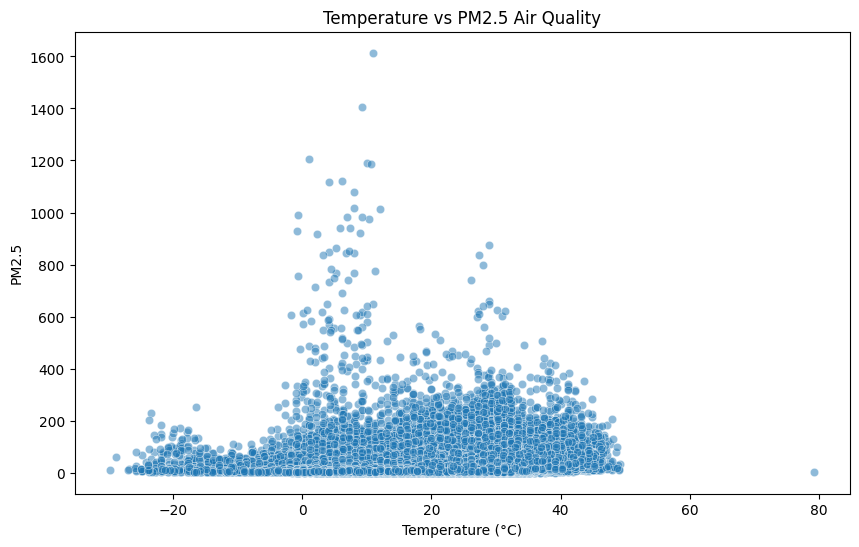

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['temperature_celsius'],
    y=df['air_quality_PM2.5'],
    alpha=0.5
)

plt.title('Temperature vs PM2.5 Air Quality')
plt.xlabel('Temperature (°C)')
plt.ylabel('PM2.5')

plt.show()

## Environmental Analysis Insights

- PM2.5 air quality values exhibit significant variability across temperature ranges.
- Most observations cluster around lower pollution levels, while several extreme pollution outliers are present.
- The relationship between temperature and air quality appears complex and non-linear.
- Environmental conditions likely depend on additional regional and atmospheric factors beyond temperature alone.

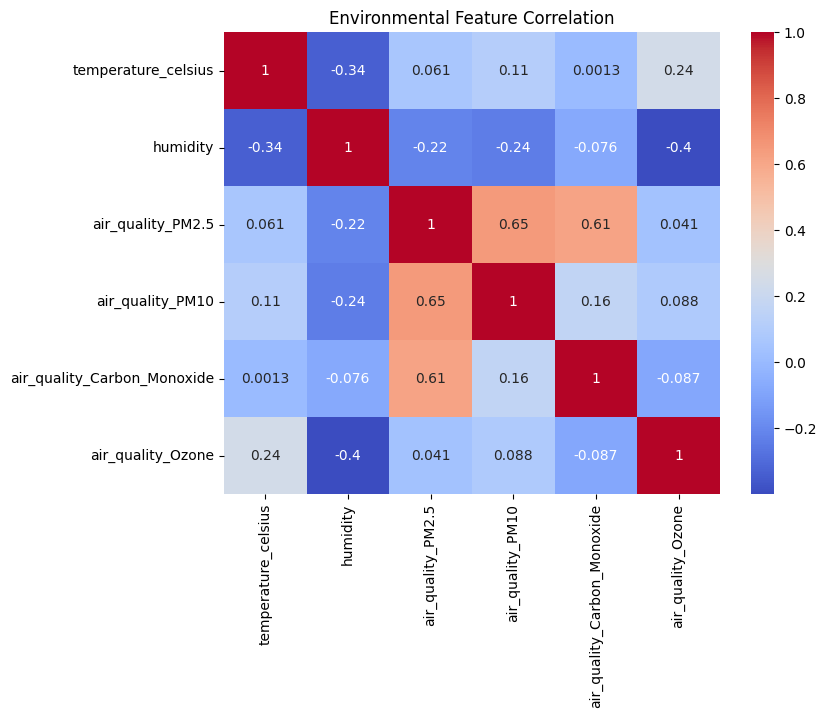

In [7]:
environment_corr = df[
    [
        'temperature_celsius',
        'humidity',
        'air_quality_PM2.5',
        'air_quality_PM10',
        'air_quality_Carbon_Monoxide',
        'air_quality_Ozone'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    environment_corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Environmental Feature Correlation')

plt.show()

## Environmental Correlation Insights

- PM2.5 and PM10 show strong positive correlation, indicating related particulate pollution behavior.
- Carbon monoxide also demonstrates a notable relationship with PM2.5 levels.
- Humidity exhibits moderate negative correlation with temperature and ozone levels.
- The results suggest complex environmental interactions between atmospheric and pollution-related variables.

## Feature Importance Exploration

This section evaluates which weather and environmental features are most strongly associated with temperature prediction.

In [9]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])

In [10]:
temperature_corr = (
    numerical_df.corr()['temperature_celsius']
    .sort_values(ascending=False)
)

temperature_corr

temperature_celsius             1.000000
temperature_fahrenheit          0.999997
feels_like_celsius              0.983834
feels_like_fahrenheit           0.983831
uv_index                        0.489447
air_quality_Ozone               0.244222
longitude                       0.139508
visibility_miles                0.112291
air_quality_PM10                0.109709
visibility_km                   0.108842
air_quality_gb-defra-index      0.095298
air_quality_us-epa-index        0.092467
wind_mph                        0.091292
wind_kph                        0.091217
gust_kph                        0.077441
gust_mph                        0.077418
air_quality_PM2.5               0.060747
precip_mm                       0.034298
precip_in                       0.034219
air_quality_Carbon_Monoxide     0.001345
moon_illumination              -0.001885
wind_degree                    -0.024213
air_quality_Sulphur_dioxide    -0.032460
cloud                          -0.128609
air_quality_Nitr

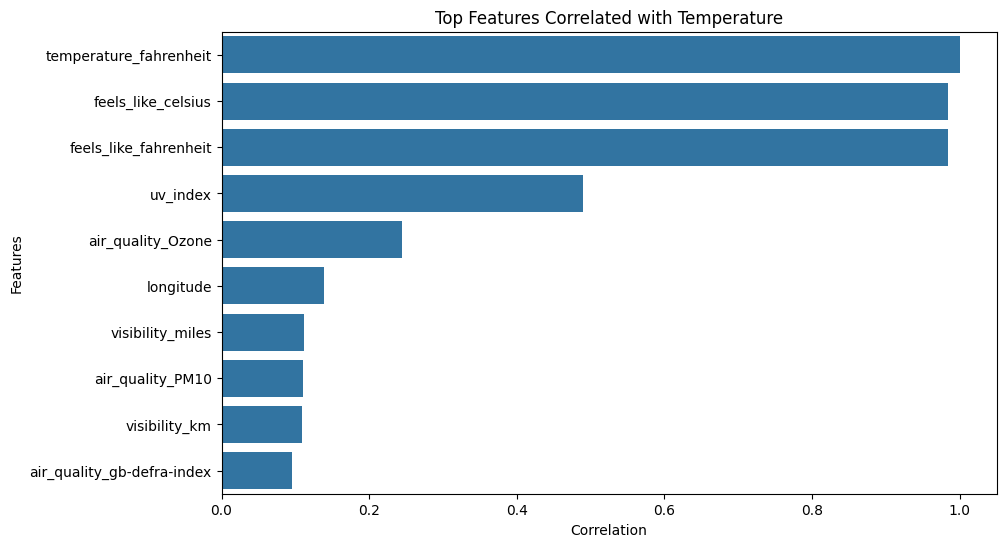

In [11]:
top_features = temperature_corr[1:11]

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title('Top Features Correlated with Temperature')
plt.xlabel('Correlation')
plt.ylabel('Features')

plt.show()

## Feature Importance Insights

- Temperature-related features such as Fahrenheit and "feels like" measurements show extremely high correlation with the target variable.
- UV index demonstrates moderate positive correlation with temperature, suggesting relationships between sunlight intensity and warmer climates.
- Environmental and visibility-related features also show weaker but meaningful relationships with temperature behavior.
- Several highly correlated variables may be removed later to reduce redundancy during forecasting model development.